In [10]:
# custom function to write html section titles and descriptions

def html(level, title, description):
    import ipywidgets as widgets
    from IPython.display import display, HTML
    display(HTML(f"""
    <a id="{title.lower().replace(" ", "-")}"></a>
    <h{level} align = "center"; style = "font-family:Times New Roman; font-variant:small-caps;">{title}</h{level}>
    <div align = "center">
    <h{level-2} align = "center"; style = "font-family:Times New Roman; font-variant:small-caps;">{description}</h{level-2}>
    </div>
    """))


In [11]:
html(1, "Graph Analysis with Matplotlib", "Week 2")

- [x] Complete several of the Matplotlib tutorials at the following link until you feel comfortable: Matplotlib Tutorials.
- [x] Using a data set of your choice, write an introduction explaining the data set.
- [x] Identify a question or question(s) that you would like to explore in your data set.
- [x] Create at least three graphs that help answer these questions.
- [ ] Make sure your graphs are clearly readable and are labeled appropriately and professionally. 
- [ ] Explain what you have learned from each of your graphs.
- [ ] Write a conclusion that summarizes your findings.

In [3]:
html(1, "Matplotlib tutorials", "")

In [4]:
import sys

modules = """
pandas
matplotlib
openpyxl
forestplot
"""

with open("./requirements.txt", "w") as f:
    f.write(modules)

!{sys.executable} -m pip install -r requirements.txt
import matplotlib.pyplot as plt

In [5]:
html(2, "Line plots", "")

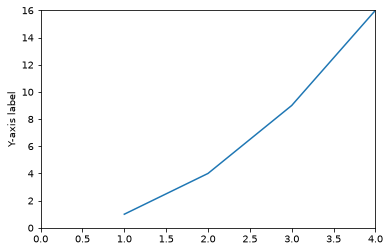

In [6]:
x = [1, 2, 3, 4]
y = [1, 4, 9, 16]
plt.plot(x, y)
plt.axis([0, 4, 0, 16])
plt.ylabel("Y-axis label")
plt.show()

In [7]:
html(2, "Plot", "")

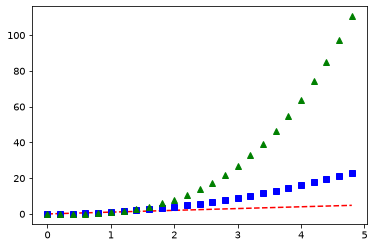

In [8]:
import numpy as np

t = np.arange(0., 5., 0.2)
plt.plot(t, t, "r--", t, t**2, "bs", t, t**3, "g^")
plt.show()

In [9]:
html(2, "Scatter Plots", "")

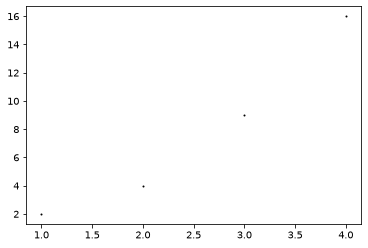

In [10]:
import pandas as pd
a = np.random.randint(1, 100, size = 10)
b = np.random.randint(1, 100, size = 10)
c = np.random.randint(1, 100, 10)
d = np.random.randint(1, 100, 10)
data = pd.DataFrame({
    "a": a,
    "b": b,
    "c": c, 
    "d": d})
plt.scatter(x = [1, 2, 3, 4], y = [2, 4, 9, 16], s = 1, c = "black", data = data)
plt.show()

In [11]:
html(2, "Subplots", "")

In [12]:
import pandas as pd

def csv(file):
    df = pd.read_csv(file, encoding = "utf-8")
    return df

def excel(file):
    df = pd.read_excel(file)
    return df


**1. Using a data set of your choice, write an introduction explaining the data set.**

In [13]:
data = csv("./data/data.csv")
data.head()

,ID,Study,Study design,LOE,N,M/F,Male,Female,Age (years),Age,...,KOOS symptoms,KOOS QoL,Pivot shift,Instrumental laxity,VAS,Graft rupture,Donor site morbidity,Arthrofibrosis,SLHT,Patellar fracture
0,1.0,"Akoto and Hoeher, 2012",Prospective cohort study,II,87.0,75/12,75.0,12.0,31 ± 7.6,31.0,...,NaN,NaN,✓,✓,NaN,✓,✓,NaN,✓,NaN
1,2.0,"Akoto et al., 2015",Prospective comparative study,II,10.0,10/0,10.0,0.0,27.4 ± 10.7,27.4,...,NaN,NaN,✓,✓,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,"Akoto et al., 2019",Retrospective comparative study,III,41.0,32/9,32.0,9.0,29 ± 10,29.0,...,NaN,NaN,✓,✓,NaN,✓,✓,NaN,✓,NaN
3,4.0,"Aslam et al., 2021",Retrospective comparative study,III,35.0,19/11,19.0,11.0,24.6 ± 3.3,24.6,...,NaN,NaN,NaN,NaN,NaN,✓,NaN,NaN,NaN,NaN
4,5.0,"Barié et al., 2010",Prospective cohort study,II,106.0,63/43,63.0,43.0,30 ± 5.4,30.0,...,NaN,NaN,✓,✓,NaN,✓,✓,✓,NaN,NaN


In [14]:
outcomes = {
    "IKDC subjective": "ikdc_subjective",
    "Lysholm": "lysholm",
    "Tegner": "tegner",
    "Instrumental laxity": "instrumental_laxity",
    "Pivot shift": "pivot_shift",
    "Lachman": "lachman",
    "Graft rupture": "graft_rupture"
}

# covariates dataset merge with sheets for analysis
for x, y in outcomes.items():
    df = csv("./data/data.csv")
    cov = df[df[x] == "✓"]
    cov = cov[["ID", "Study", "Age", "Follow-up", "M/F"]]
    analysis = csv(f"./data/{y}.csv")  
    cov["ID"] = cov.set_index
    analysis["id"] = analysis.set_index
    data = analysis.merge(right = cov, how = "outer", on = cov["ID"])
    globals()[f"{y}"] = data

These datasets are data extracted from studies that reported the specific outcome in patients who had undergone surgery using either one of two surgical techniques.

IKDC subjective knee form, Lysholm knee scoring scale, and Tegner activity scale are patient-reported outcome measures (PROMs) that are used to evaluate the patients' quality of life. It is frequently used before and after the surgery, with various follow-up durations (time after surgery) to see if there is an improvement in the patients' overall wellbeing and knee function in relation to daily living compared to baseline. 

Instrumental laxity, pivot shift test and Lachman test are objective measures of knee stability. Instrumental laxity and Lachman measure anteroposterior (AP) translational stability while pivot shift measures rotational stability of the knee. Instrumental laxity dataset contains continuous data in millimeters of the side-to-side difference in AP translation (how much the tibia and femur move in relation to each other) compared with the healthy knee. Pivot shift and Lachman are graded categorically with 4 levels in both tests.

Graft rupture is a dataset containing binary data or categorical data with only two levels. 

**2. Identify a question or question(s) that you would like to explore in your data set.**

Does follow up duration, mean age, and gender of the patients have an effect on the visual representations of the effect sizes? In order to explore this research question, follow up duration, mean age and gender of the patients were included in a dataset from a previous project to plot the data points separately by binning the covariates into subsets. 

**3. Create at least three graphs that help answer these questions.  
     Make sure your graphs are clearly readable and are labeled appropriately and professionally.**

In [15]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import scatter

outcomes = {
    "IKDC Subjective": ikdc_subjective, 
    "Lysholm Knee Scoring Scale": lysholm, 
    "Tegner Activity Scale": tegner, 
    "Instrumental laxity": instrumental_laxity, 
    "Pivot shift": pivot_shift, 
    "Lachman": lachman, 
    "Graft rupture": graft_rupture
}

In [16]:
!pip install forestplot

In [17]:
import forestplot as fp
import pandas as pd
df = csv("./data/data.csv")
data = pd.read_excel("./data/outcome.xlsx")
df = df.fillna("")
data.head()

ValueError: invalid literal for int() with base 10: '5.3'

In [ ]:
ikdc_plot = fp.forestplot(
        dataframe = data,
        estimate = "yi",
        ll = "ci.lb",
        hl = "ci.ub",
        varlabel = "study",
        xlabel = "IKDC Subjective",
        ylabel = "Studies"
)

ikdc_plot

30 days. 

The continuous covariates were plotted using .
The dichotomous covariates were plotted using .

**Covariables for plotting and linear regression**

In [ ]:
df = csv("./data/data.csv")

df.head()

In [ ]:
# covariates 1
df = ikdc_subjective
ikdc_subjective_s = df[df["graft_type"] == "S-QT"]
pediatric = ikdc_subjective_s[ikdc_subjective_s["Age"] < 18]
adult = ikdc_subjective_s[ikdc_subjective_s["Age"].between(18, 50)]
elderly = ikdc_subjective_s[ikdc_subjective_s["Age"] >= 50]
follow_up = ikdc_subjective_s["Follow-up"]
gender = ikdc_subjective_s["M/F"]
y = ikdc_subjective_s["yi"]

S_QT = ikdc_subjective_s
S_QT.head()

# covariates 2
ikdc_subjective_b = df[df["graft_type"] == "B-QT"]
pediatric = ikdc_subjective_b[ikdc_subjective_b["Age"] < 18]
adult = ikdc_subjective_b[ikdc_subjective_b["Age"].between(18, 50)]
elderly = ikdc_subjective_b[ikdc_subjective_b["Age"] >= 50]
age = ikdc_subjective_b["Age"]
follow_up = ikdc_subjective_b["Follow-up"]
gender = ikdc_subjective_b["M/F"]
y = ikdc_subjective_b["yi"]

B_QT = ikdc_subjective_b
B_QT.head()

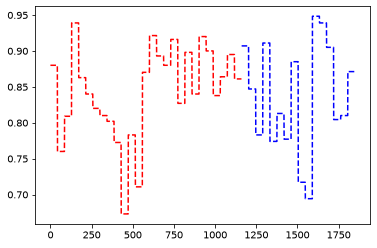

In [18]:
df = ikdc_subjective

S = df[df["graft_type"] == "S-QT"] 
B = df[df["graft_type"] == "B-QT"]

plt.plot(S["yi"]/100, "b--") # S-QT
plt.plot(B["yi"]/100, "r--") # B-QT

plt.show()

In the IKDC subjective knee form dataset, B-QT definitely has data points with higher values and less dispersion than those of the S-QT subgroup. 

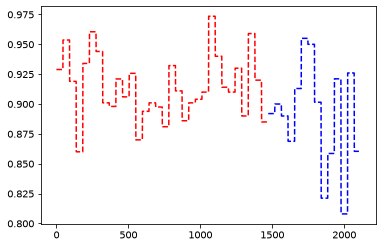

In [20]:
df = lysholm

S = df[df["graft_type"] == "S-QT"] 
B = df[df["graft_type"] == "B-QT"]

plt.plot(S["yi"]/100, "b--") # S-QT
plt.plot(B["yi"]/100, "r--") # B-QT

plt.show()

In Lysholm dataset, the S-QT subgroup appears to have more overall dispersion than the B-QT subgroup.

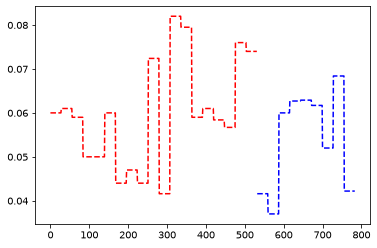

In [19]:
df = tegner

S = df[df["graft_type"] == "S-QT"] 
B = df[df["graft_type"] == "B-QT"]

plt.plot(S["yi"]/100, "b--") # S-QT
plt.plot(B["yi"]/100, "r--") # B-QT
plt.show()

In the Tegner dataset, the S-QT subgroup has lower values but lower dispersion ranges. B-QT has higher values but more dispersion ranges in this dataset.

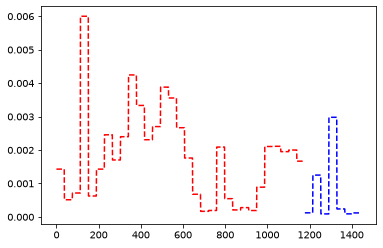

In [32]:
df = pivot_shift

S = df[df["graft_type"] == "S-QT"] 
B = df[df["graft_type"] == "B-QT"]

plt.plot(S["yi"]/100, "b--") # S-QT
plt.plot(B["yi"]/100, "r--") # B-QT
plt.show()

Pivot shift dataset shows that B-QT has much more rotational instability than S-QT. The highest value of rotational instability is 0.006. 

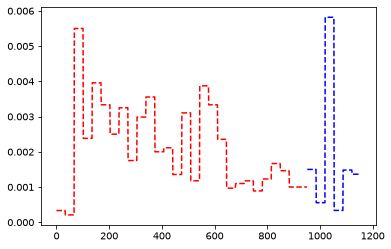

In [22]:
df = lachman

S = df[df["graft_type"] == "S-QT"] 
B = df[df["graft_type"] == "B-QT"]

plt.plot(S["yi"]/100, "b--") # S-QT
plt.plot(B["yi"]/100, "r--") # B-QT
plt.show()

The Lachman test shows that B-QT has more values than the S-QT data point, but the highest value of Lachman is in the S-QT subgroup. This shows the greatest number of a positive Lachman test within a single study.

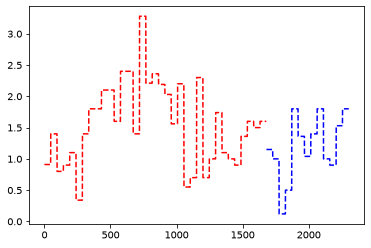

In [24]:
df = instrumental_laxity

S = df[df["graft_type"] == "S-QT"] 
B = df[df["graft_type"] == "B-QT"]


plt.plot(S["yi"], "b--") # S-QT
plt.plot(B["yi"], "r--") # B-QT
plt.show()

This dataset of instrumental laxity (side-to-side difference in millimeters) shows that there is more anteroposterior translational difference between limbs in patients that underwent ACLR with B-QT than S-QT. 

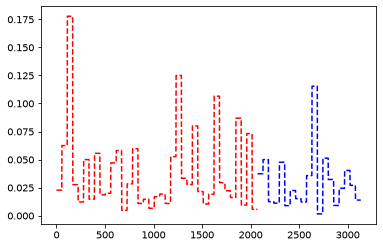

In [26]:
df = graft_rupture

S = df[df["graft_type"] == "S-QT"] 
B = df[df["graft_type"] == "B-QT"]


plt.plot(S["yi"], "b--") # S-QT
plt.plot(B["yi"], "r--") # B-QT
plt.show()

Graft rupture dataset shows that there is a cluster of data points around the 25% to 50% graft rupture rate for both subgroups. There are higher values for the B-QT subgroup, and more dispersion ranges for B-QT than S-QT.

**5. Write a conclusion that summarizes your findings.**

The conclusion obtained for IKDC Subjective, Lysholm, and Tegner Activity Score is that the subjective patient satisfaction after ACLR remains highest for B-QT but dispersion mainly is lower for S-QT. 

Pivot shift, Lachman, and instrumental laxity shows greater instability, both anteroposterior and rotational for B-QT.

Graft rupture is higher for B-QT but S-QT shows less variation and spread.